In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from ultralytics import YOLO

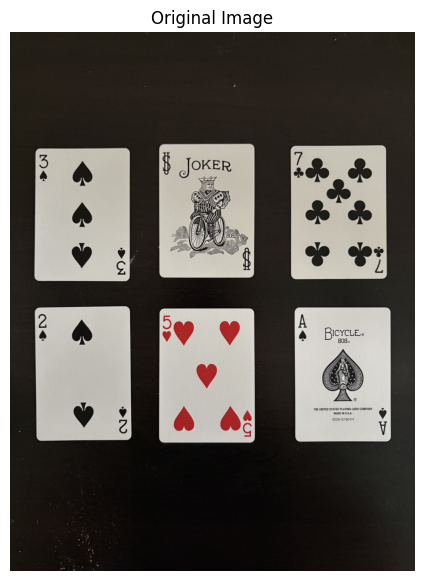

In [21]:
img = cv2.imread("test.jpg")
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

In [3]:
# convert to grayscale and blur to reduce noise
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

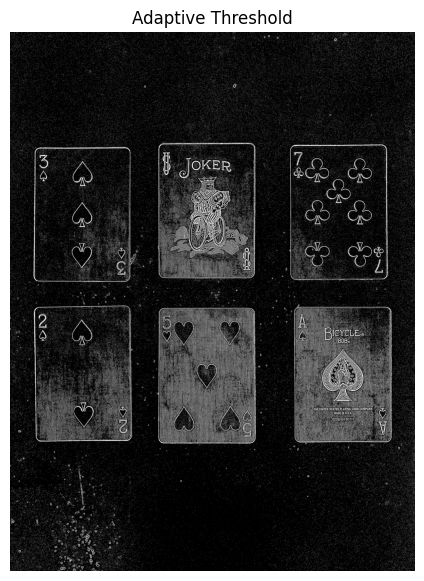

In [4]:
# adaptive threshold to separate cards from background
thresh = cv2.adaptiveThreshold(blur, 170, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

plt.figure(figsize=(10, 7))
plt.imshow(thresh, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")
plt.show()

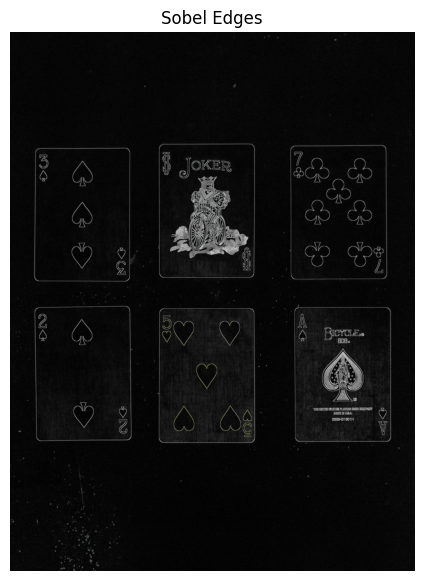

In [5]:
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

abs_sobelx = cv2.convertScaleAbs(sobelx)
abs_sobely = cv2.convertScaleAbs(sobely)
gradient_magnitude = cv2.addWeighted(abs_sobelx, 0.5, abs_sobely, 0.5, 0) 

plt.figure(figsize=(10, 7))
plt.imshow(gradient_magnitude, cmap="gray")

plt.title("Sobel Edges")
plt.axis("off")
plt.show()

In [6]:
# dilate threshold to close gaps, then find external contours
kernel = np.ones((3, 3), np.uint8)
thresh_dilated = cv2.dilate(thresh, kernel, iterations=2)
contours, _ = cv2.findContours(thresh_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)
print(f"Total contours found: {len(contours)}")

Total contours found: 56572


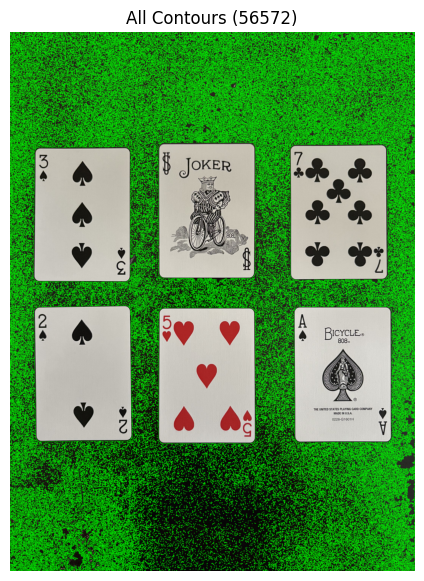

In [7]:
contour_debug = img.copy()
cv2.drawContours(contour_debug, contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(contour_debug, cv2.COLOR_BGR2RGB))
plt.title(f"All Contours ({len(contours)})")
plt.axis("off")
plt.show()

In [8]:
# filter contours to find card-shaped objects
max_area = cv2.contourArea(contours[0])
min_area = max_area * 0.1

card_contours = []

for c in contours:
    area = cv2.contourArea(c)
    if area < min_area:
        continue

    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)

    x, y, w, h = cv2.boundingRect(c)
    aspect_ratio = w / float(h)

    # a card is roughly rectangular with reasonable aspect ratio
    if 4 <= len(approx) <= 6 and 0.4 < aspect_ratio < 1.8:
        card_contours.append(c)

print(f"Cards found after filtering: {len(card_contours)}")

Cards found after filtering: 6


In [9]:
# sort cards in reading order top-to-bottom, left-to-right
bboxes = [cv2.boundingRect(c) for c in card_contours]
avg_h = np.mean([b[3] for b in bboxes])
row_thresh = avg_h * 0.4  # tolerance for same row

# pair contours with bounding boxes and sort by y
indexed = list(zip(card_contours, bboxes))
indexed.sort(key=lambda item: item[1][1])

# group into rows
rows = []
current_row = [indexed[0]]
for item in indexed[1:]:
    if abs(item[1][1] - current_row[0][1][1]) < row_thresh:
        current_row.append(item)
    else:
        rows.append(current_row)
        current_row = [item]
rows.append(current_row)

# sort each row by x, then flatten
card_contours = []
for row in rows:
    row.sort(key=lambda item: item[1][0])
    card_contours.extend([item[0] for item in row])

In [10]:
# draw bounding boxes and label each card
output = img.copy()
for i, c in enumerate(card_contours, 1):
    hull = cv2.convexHull(c)
    peri = cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, 0.02 * peri, True)
    x, y, w, h = cv2.boundingRect(hull)
    cv2.drawContours(output, [approx], -1, (0, 255, 0), 4)
    cv2.putText(output, f"Card {i}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 4.0, (0, 255, 0), 8,)
    
    print(f"  Card {i}: area={int(cv2.contourArea(c))}, ", f"corners={len(approx)}, aspect_ratio={w/float(h):.2f}")

print(f"\nTotal cards found: {len(card_contours)}")

  Card 1: area=1477632,  corners=4, aspect_ratio=0.78
  Card 2: area=1490177,  corners=4, aspect_ratio=0.70
  Card 3: area=1494670,  corners=4, aspect_ratio=0.70
  Card 4: area=1468696,  corners=4, aspect_ratio=0.74
  Card 5: area=1482501,  corners=4, aspect_ratio=0.74
  Card 6: area=1496436,  corners=4, aspect_ratio=0.74

Total cards found: 6


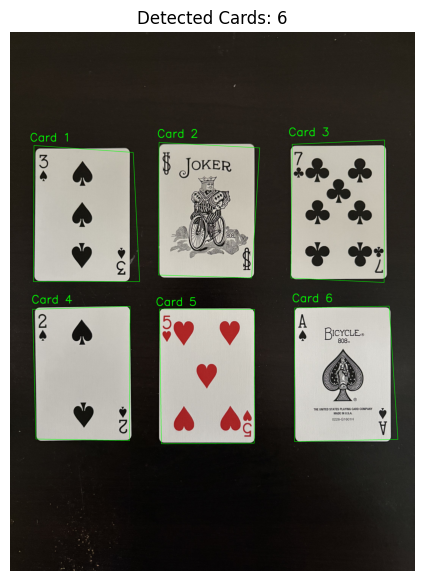

In [11]:
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Cards: {len(card_contours)}")
plt.axis("off")
plt.show()

  Card 1: 3s (81%) (matches: 1)
  Card 2: Joker (matches: 0)
  Card 3: 7c (75%) (matches: 2)
  Card 4: 2s (89%) (matches: 2)
  Card 5: 5h (82%) (matches: 2)
  Card 6: As (44%) (matches: 1)

Total cards detected (OpenCV): 6
YOLO detections available: 8


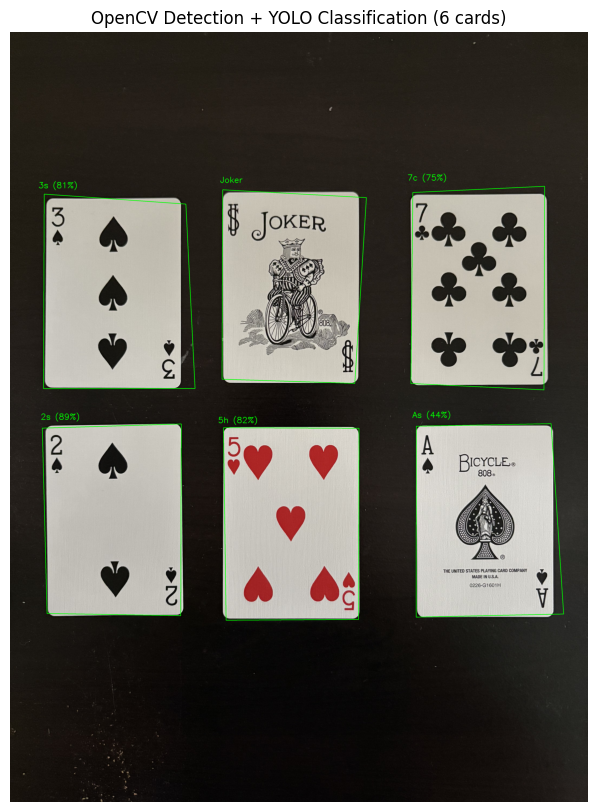

In [20]:
model = YOLO("PlayingCards.pt")

results = model.predict(img, conf=0.40, imgsz=640, verbose=False)

# Build a lookup: for each YOLO detection, store bbox + label + center
yolo_boxes = []
for box in results[0].boxes:
    x1, y1, x2, y2 = box.xyxy[0].int().tolist()
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2
    yolo_boxes.append({
        "bbox": (x1, y1, x2, y2),
        "center": (cx, cy),
        "label": model.names[cls_id],
        "conf": conf,
    })

output = img.copy()
for i, c in enumerate(card_contours, 1):
    hull = cv2.convexHull(c)
    peri = cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, 0.02 * peri, True)
    x, y, w, h = cv2.boundingRect(hull)

    matches = []
    for yb in yolo_boxes:
        cx, cy = yb["center"]
        inside = cv2.pointPolygonTest(hull, (float(cx), float(cy)), False)
        if inside >= 0:
            matches.append(yb)

    label = "Joker"
    if matches:
        best = max(matches, key=lambda m: m["conf"])
        label = f"{best['label']} ({best['conf']:.0%})"

    cv2.drawContours(output, [approx], -1, (0, 255, 0), 4)
    cv2.putText(output, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 2.0, (0, 255, 0), 4)
    print(f"  Card {i}: {label} (matches: {len(matches)})")

print(f"\nTotal cards detected (OpenCV): {len(card_contours)}")
print(f"YOLO detections available: {len(yolo_boxes)}")

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"OpenCV Detection + YOLO Classification ({len(card_contours)} cards)")
plt.axis("off")
plt.show()